In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e7/train.csv
/kaggle/input/competitions/playground-series-s6e7/test.csv


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/train.csv")

test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/test.csv")

sample = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv")

In [4]:
train.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [5]:
train.shape

(690088, 15)

In [6]:
test.shape

(295753, 14)

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [8]:
train.isnull().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [9]:
train["health_condition"].value_counts()

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

In [10]:
train.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [11]:
num_cols = train.select_dtypes(include=["int64","float64"]).columns

cat_cols = train.select_dtypes(include=["object"]).columns

In [12]:
num_cols

Index(['id', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
       'step_count', 'exercise_duration', 'water_intake'],
      dtype='object')

In [13]:
cat_cols

Index(['health_condition', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='object')

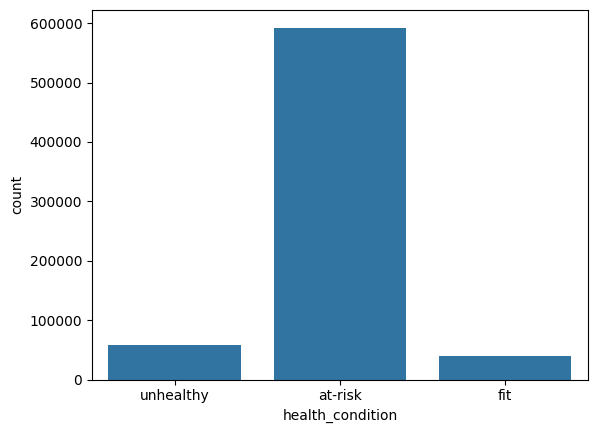

In [14]:
sns.countplot(data=train,x="health_condition")
plt.show()

<Axes: xlabel='bmi', ylabel='Count'>

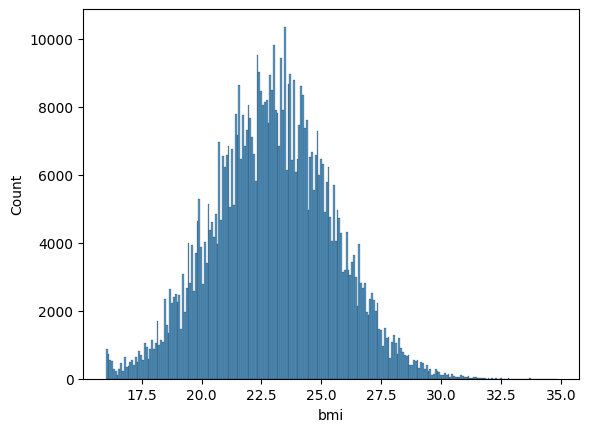

In [15]:
sns.histplot(train["bmi"])

<Axes: xlabel='health_condition', ylabel='heart_rate'>

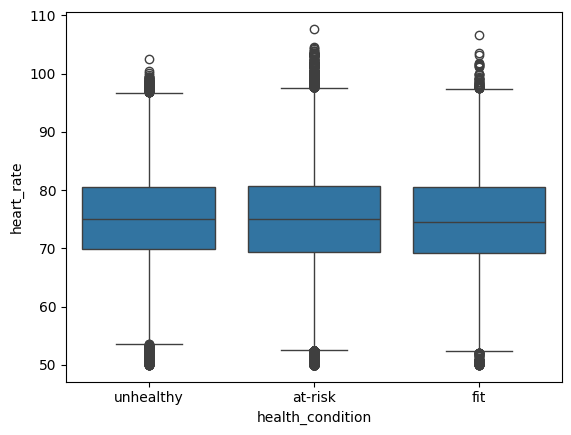

In [16]:
sns.boxplot(
    x="health_condition",
    y="heart_rate",
    data=train
)

<Axes: xlabel='gender', ylabel='count'>

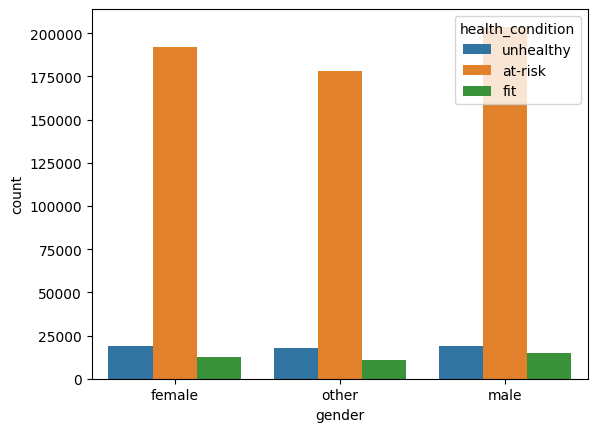

In [17]:
sns.countplot(
    x="gender",
    hue="health_condition",
    data=train
)

<Axes: xlabel='diet_type', ylabel='count'>

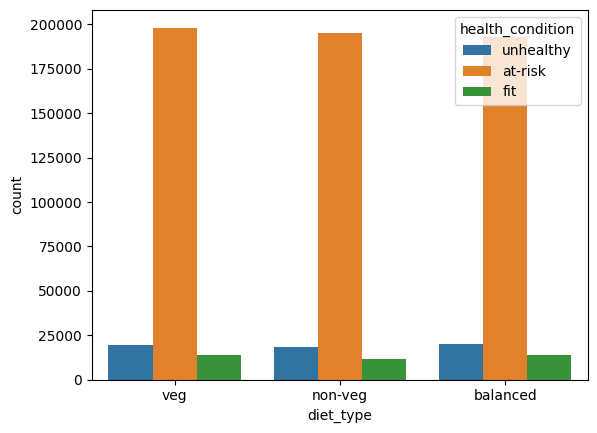

In [18]:
sns.countplot(
    x="diet_type",
    hue="health_condition",
    data=train
)

<Axes: >

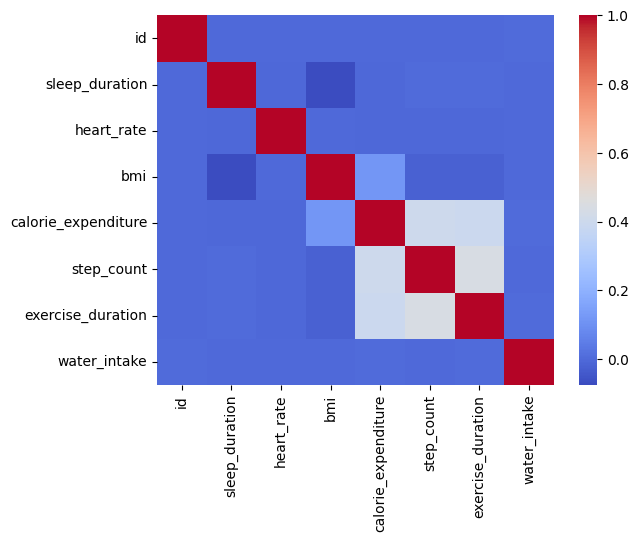

In [19]:
corr = train[num_cols].corr()

sns.heatmap(corr,cmap="coolwarm")

In [20]:
X = train.drop(
    columns=["health_condition","id"]
)

y = train["health_condition"]

In [21]:
X_test = test.drop(columns=["id"])

In [22]:
X_test

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295748,7.13,77.5,22.20,2221.0,13981.0,65.6,2.17,balanced,low,average,active,occasional,other
295749,6.25,69.5,20.93,2242.0,2370.0,23.6,1.98,balanced,NaN,average,moderate,yes,female
295750,NaN,77.0,23.62,2111.0,7647.0,25.1,2.18,veg,high,average,sedentary,no,other
295751,7.25,66.3,21.47,2009.0,4672.0,25.1,2.02,veg,high,poor,moderate,no,female


In [23]:
cat_cols= X.select_dtypes(include='object').columns

In [24]:
X[cat_cols].isnull().sum()

diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [25]:
X[cat_cols] = X[cat_cols].fillna("Missing")
X_test[cat_cols] = X_test[cat_cols].fillna("Missing")

In [26]:
X[cat_cols]

,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,veg,high,average,sedentary,yes,female
1,non-veg,low,average,moderate,yes,other
2,veg,high,poor,active,yes,male
3,veg,high,average,active,occasional,female
4,veg,Missing,average,sedentary,Missing,male
...,...,...,...,...,...,...
690083,non-veg,high,poor,active,yes,female
690084,veg,medium,average,moderate,no,male
690085,non-veg,Missing,average,active,no,male
690086,balanced,Missing,average,active,yes,male


In [27]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X[cat_cols] = encoder.fit_transform(X[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

In [28]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

X[num_cols].isnull().sum()

sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                      0
stress_level                   0
sleep_quality                  0
physical_activity_level        0
smoking_alcohol                0
gender                         0
dtype: int64

In [29]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")

X[num_cols] = num_imputer.fit_transform(X[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

In [30]:
X[num_cols]

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,3.0,1.0,1.0,3.0,3.0,1.0
1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,2.0,2.0,1.0,2.0,3.0,3.0
2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,3.0,1.0,3.0,1.0,3.0,2.0
3,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,3.0,1.0,1.0,1.0,2.0,1.0
4,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,3.0,0.0,1.0,3.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,6.31,69.7,24.11,2157.0,8856.0,30.8,3.00,2.0,1.0,3.0,1.0,3.0,1.0
690084,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,3.0,3.0,1.0,2.0,1.0,2.0
690085,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,2.0,0.0,1.0,1.0,1.0,2.0
690086,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,1.0,0.0,1.0,1.0,3.0,2.0


In [31]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(train["health_condition"])

In [32]:
y

array([2, 0, 2, ..., 1, 0, 0])

In [33]:

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [34]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [35]:
num_classes = len(label_encoder.classes_)

In [36]:
oof_xgb = np.zeros(len(X))

test_pred_xgb = np.zeros((len(X_test), num_classes))

In [37]:
oof_cat = np.zeros(len(X))

test_pred_cat = np.zeros((len(X_test), num_classes))

In [38]:
oof_lgb = np.zeros(len(X))

test_pred_lgb = np.zeros((len(X_test), num_classes))

In [39]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    eval_metric="mlogloss"
)

In [40]:
fold_scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):

    print(f"\nFold {fold}")

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y[train_idx]
    y_valid = y[valid_idx]

    xgb_model.fit(X_train, y_train)

    valid_pred = xgb_model.predict(X_valid)

    score = balanced_accuracy_score(y_valid, valid_pred)

    fold_scores.append(score)

    print("Balanced Accuracy:", score)

    oof_xgb[valid_idx] = valid_pred

    test_pred_xgb += xgb_model.predict_proba(X_test) / skf.n_splits


Fold 1
Balanced Accuracy: 0.8778092598323851

Fold 2
Balanced Accuracy: 0.8810377703013921

Fold 3
Balanced Accuracy: 0.8809105725382134

Fold 4
Balanced Accuracy: 0.8766868074710809

Fold 5
Balanced Accuracy: 0.8782312532762159


In [41]:
print("-" * 40)
print("Mean CV Score:", np.mean(fold_scores))

----------------------------------------
Mean CV Score: 0.8789351326838574


In [42]:
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="MultiClass",
    verbose=0,
    random_seed=42
)

In [43]:
cat_fold_scores = []
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):

    print(f"\n{'='*40}")
    print(f"CatBoost Fold {fold}")
    print(f"{'='*40}")

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y[train_idx]
    y_valid = y[valid_idx]

    cat_model.fit(
        X_train,
        y_train
    )

    valid_pred = cat_model.predict(X_valid)

    # Convert prediction shape from (n,1) to (n,)
    valid_pred = valid_pred.astype(int).flatten()

    # Balanced Accuracy
    score = balanced_accuracy_score(
        y_valid,
        valid_pred
    )

    cat_fold_scores.append(score)

    print(f"Balanced Accuracy : {score:.5f}")

    # Store OOF predictions
    oof_cat[valid_idx] = valid_pred

    # Store Test Probabilities
    test_pred_cat += (
        cat_model.predict_proba(X_test)
        / skf.n_splits
    )


CatBoost Fold 1
Balanced Accuracy : 0.86848

CatBoost Fold 2
Balanced Accuracy : 0.87287

CatBoost Fold 3
Balanced Accuracy : 0.87078

CatBoost Fold 4
Balanced Accuracy : 0.86749

CatBoost Fold 5
Balanced Accuracy : 0.86951


In [44]:
print("="*50)

print("Mean Balanced Accuracy")

print(np.mean(cat_fold_scores))

Mean Balanced Accuracy
0.8698263394504986


In [45]:
lgb_model = LGBMClassifier(
    objective="multiclass",
    num_class=num_classes,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [46]:
lgb_fold_scores = []
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):

    print(f"\n{'='*40}")
    print(f"LightGBM Fold {fold}")
    print(f"{'='*40}")

    # Split Data
    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y[train_idx]
    y_valid = y[valid_idx]

    # Train Model
    lgb_model.fit(
        X_train,
        y_train
    )

    # Validation Prediction
    valid_pred = lgb_model.predict(X_valid)

    # Balanced Accuracy
    score = balanced_accuracy_score(
        y_valid,
        valid_pred
    )

    lgb_fold_scores.append(score)

    print(f"Balanced Accuracy : {score:.5f}")

    # Store Out-of-Fold Predictions
    oof_lgb[valid_idx] = valid_pred

    # Predict Test Probabilities
    test_pred_lgb += (
        lgb_model.predict_proba(X_test)
        / skf.n_splits
    )


LightGBM Fold 1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.041164 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1808
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 13
[LightGBM] [Info] Start training from score -0.152364
[LightGBM] [Info] Start training from score -2.852889
[LightGBM] [Info] Start training from score -2.481150
Balanced Accuracy : 0.87577

LightGBM Fold 2
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012556 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1809
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 13
[LightGBM] [Info] Start training from score -0.152364
[LightGBM] [Info] Start training from score -2.852889
[LightGBM] [Info] Start 

In [47]:
print("="*50)

print("Mean Balanced Accuracy")

print(np.mean(lgb_fold_scores))

Mean Balanced Accuracy
0.876855861338786


In [48]:
ensemble_prob = (
    test_pred_xgb +
    test_pred_cat +
    test_pred_lgb
) / 3

In [49]:
ensemble_prob

array([[1.00302949e-02, 2.72948790e-03, 9.87240211e-01],
       [5.18455335e-01, 3.19155367e-03, 4.78353109e-01],
       [9.97204461e-01, 2.07689792e-03, 7.18626984e-04],
       ...,
       [7.57365247e-01, 5.01475950e-03, 2.37619995e-01],
       [9.95571847e-01, 3.06611734e-03, 1.36203608e-03],
       [3.13726074e-03, 3.17036473e-03, 9.93692363e-01]])

In [50]:
final_prediction = np.argmax(ensemble_prob, axis=1)

In [51]:
final_prediction = label_encoder.inverse_transform(final_prediction)

In [52]:
final_prediction

array(['unhealthy', 'at-risk', 'at-risk', ..., 'at-risk', 'at-risk',
       'unhealthy'], dtype=object)

In [53]:
final_prediction.shape

(295753,)

In [54]:
submission = pd.DataFrame({
    "id": test["id"],
    "health_condition": final_prediction
})

submission.head()

,id,health_condition
0,690088,unhealthy
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


In [55]:
submission.to_csv("submission.csv", index=False)